# Figure 2

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py
import codecs

import EIANN.utils as ut
import EIANN.plot as pt

from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/data_utils.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# Load model specs from csv file
csv_file_path = root_dir + "/EIANN/data/figure_model_specs.csv" 
df = pd.read_csv(csv_file_path, index_col=0)
df = df.map(lambda x: codecs.decode(x, 'unicode_escape') if isinstance(x, str) else x) # convert special characters like \n
model_dict_all = df.transpose().to_dict()
seeds = ["66049_257","66050_258", "66051_259", "66052_260", "66053_261"]
for model_key in model_dict_all:
    model_dict_all[model_key]["seeds"] = seeds

In [11]:
figure_name = "Fig2_vanBP_bpDale_hebb"
model_list = ["vanBP", "bpDale_learned", "HebbWN_topsup"]

config_path_prefix = root_dir + "/EIANN/network_config/mnist/"
# saved_network_path_prefix = root_dir + "/EIANN/data/saved_network_pickles/mnist/"

# Set path to Box data directory (default path based on OS)
if os.name == "posix": # macOS or Linux
    username = os.environ.get("USER")
    saved_network_path_prefix = f"/Users/{username}/Library/CloudStorage/Box-Box/Milstein-Shared/EIANN exported data/2024 Manuscript V2/MNIST/"
elif os.name == "nt": # Windows
    username = os.environ.get("USERNAME")
    saved_network_path_prefix = f"C:/Users/{username}/Box/Milstein-Shared/EIANN exported data/2024 Manuscript V2/MNIST/"

hdf5_path_prefix = root_dir + "/EIANN/data/model_hdf5_plot_data/"
generate_hdf5_all_seeds(model_list, model_dict_all, config_path_prefix, saved_network_path_prefix, hdf5_path_prefix, recompute=None)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)


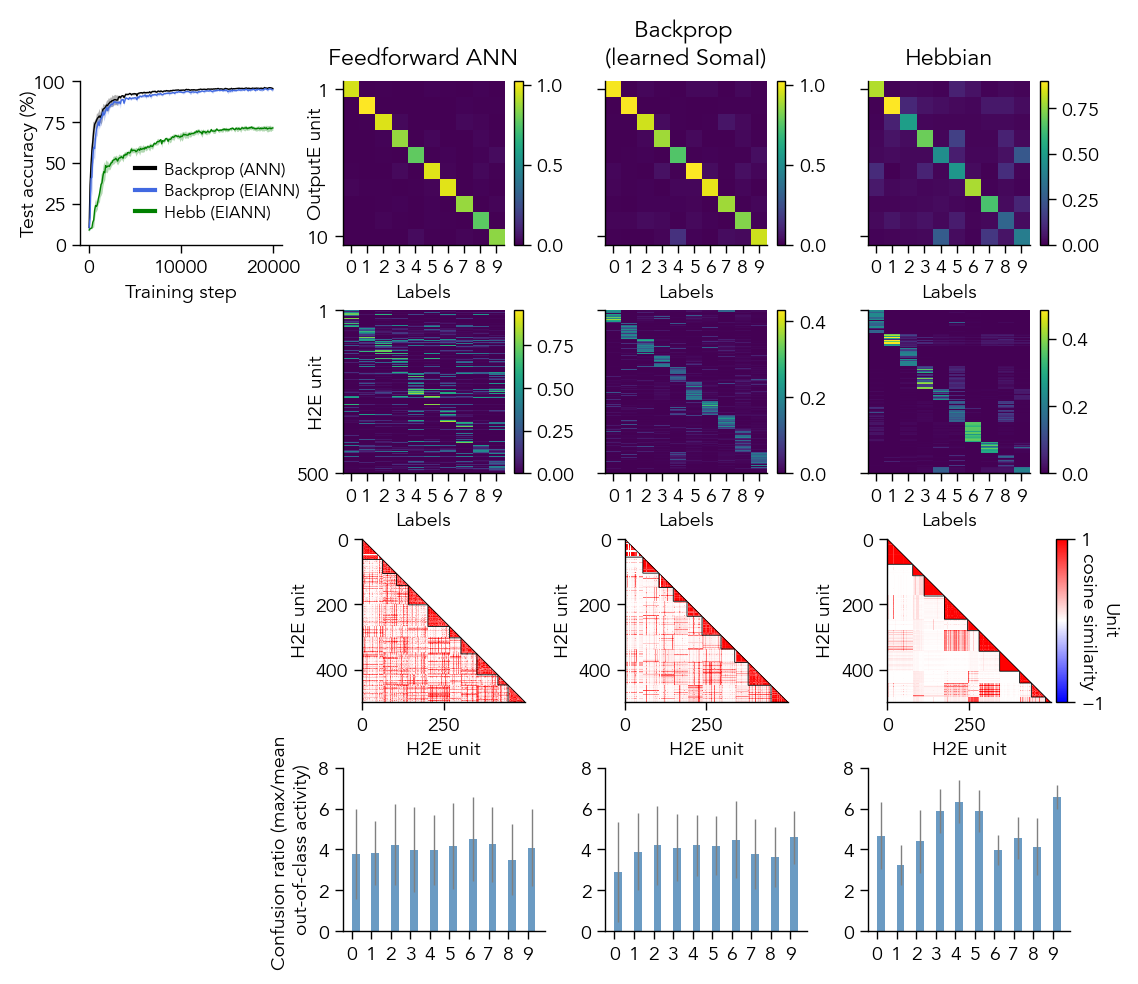

In [22]:
fig = plt.figure(figsize=(5.5, 5))
axes = gs.GridSpec(nrows=4, ncols=4, figure=fig,                    
                    left=0.05,right=0.95,
                    top=0.95, bottom=0.1,
                    wspace=0.3, hspace=0.4)

ax_accuracy    = fig.add_subplot(axes[0, 0])  


for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = hdf5_path_prefix + f"plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)

        example_seed = model_dict['seeds'][0]
        ax1 = fig.add_subplot(axes[0, col+1])
        ax2 = fig.add_subplot(axes[1, col+1])
        ax1.set_ylabel('OutputE unit', labelpad=-7)
        ax2.set_ylabel('H2E unit', labelpad=-11)        
        ax = [ax1, ax2]
        for row, population in enumerate(['OutputE', 'H2E']):
            # Activity plots: batch accuracy of each population to the test dataset
            average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
            num_units = average_pop_activity_dict[population].shape[1]

            pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax[row], cbar=True)            
            ax[row].set_yticks([0,num_units-1])
            ax[row].set_yticklabels([1,num_units])
            if col > 0:
                ax[row].set_yticklabels([])
                ax[row].set_ylabel('')

        ax1.set_title(model_dict["display_name"])

        # Class confusion plots
        ax = fig.add_subplot(axes[2, col+1])
        between_class_similarity = {label: [] for label in range(10)}
        between_class_similarity_all = []
        for seed in model_dict['seeds']:
            # Calculate the receptive field similarity for each unit (the histogram will pool data across all model seeds)
            unit_labels_dict = data_dict[seed]['unit_labels_dict']
            unit_labels = unit_labels_dict[population][:]
            idx = np.argsort(unit_labels)
            unit_labels = unit_labels[idx]

            # Alternative 1: compare unit activities (class averaged)
            average_pop_activity = np.array(data_dict[seed]['average_pop_activity_dict'][population][:]).T
            sorted_receptive_fields = average_pop_activity[idx]

            # # Alternative 2: compare unit activities (full)
            # pop_activity_dict = data_dict[seed]['sorted_activity_dict']
            # unit_labels = data_dict[seed]['sorted_unit_labels_dict'][population][:]
            # sorted_receptive_fields = np.array(pop_activity_dict[population][:]).T

            rf_similarity = cosine_similarity(sorted_receptive_fields)
            np.fill_diagonal(rf_similarity, 0) # remove self-similarity

            # Plot the receptive field similarity matrix for the example seed
            if seed == example_seed:
                masked_rf_similarity = np.ma.masked_array(rf_similarity, mask=~np.tril(np.ones(rf_similarity.shape), k=-1).astype(bool))
                im = ax.imshow(masked_rf_similarity, interpolation="nearest", cmap='bwr', vmin=-1, vmax=1)
                ax.set_xlabel(f"{population} unit")
                ax.set_ylabel(f"{population} unit")
                if col==len(model_list)-1:
                    cax = fig.add_axes([ax.get_position().x1+0.005, ax.get_position().y0, 0.01, ax.get_position().height])
                    fig.colorbar(im, cax=cax, orientation='vertical')
                    cax.set_yticks([-1, 1])
                    # cax.set_yticks([0, 1])
                    cax.set_ylabel('Unit\ncosine similarity', rotation=270, labelpad=5)
            
            # Calculate within-class and between-class receptive field similarity (accumulate across all seeds)
            for label in range(10):
                class_idx = np.where(unit_labels == label)[0]
                max_activity_outside_class = np.max(sorted_receptive_fields[class_idx][:, np.arange(10)!=label], axis=1)
                mean_activity_outside_class = np.mean(sorted_receptive_fields[class_idx][:, np.arange(10)!=label], axis=1)
                confusion_ratio = max_activity_outside_class / (mean_activity_outside_class + 1e-10)

                between_class_similarity_all.extend(confusion_ratio)
                between_class_similarity[label].extend(confusion_ratio)
                if len(class_idx) > 0: # Add triangle to indicate units within the same class
                    class_boundary_start = class_idx[0]
                    class_boundary_end = class_idx[-1]+1
                    top = (class_boundary_start-0.5, class_boundary_start-0.5)
                    bottom = (class_boundary_start-0.5, class_boundary_end-0.5)
                    right = (class_boundary_end-0.5, class_boundary_end-0.5)
                    if seed == example_seed:
                        ax.add_patch(matplotlib.patches.Polygon([bottom, top, right], fill=False, edgecolor='k', linewidth=0.3))
        
        # Bar graph of mean within and between class similarities for each class
        ax = fig.add_subplot(axes[3, col+1])
        for label in range(10):
            mean_val = np.mean(between_class_similarity[label])
            std_val = np.std(between_class_similarity[label])
            ax.bar(label + 0.2, mean_val, width=0.4, label='Between-class' if label==0 else None, color='steelblue', alpha=0.8)
            ax.errorbar(label + 0.2, mean_val, yerr=std_val, fmt='none', ecolor='gray', capsize=0, linewidth=0.5)
        if col == 0:
            ax.set_ylabel('Confusion ratio (max/mean \nout-of-class activity)')
        ax.set_xticks(range(10))
        ax.set_xticklabels(range(10))
        ax.set_ylim(0, 8)

# fig.savefig(f"figures/{figure_name}.svg", dpi=300)
# fig.savefig(f"figures/{figure_name}.png", dpi=300)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)


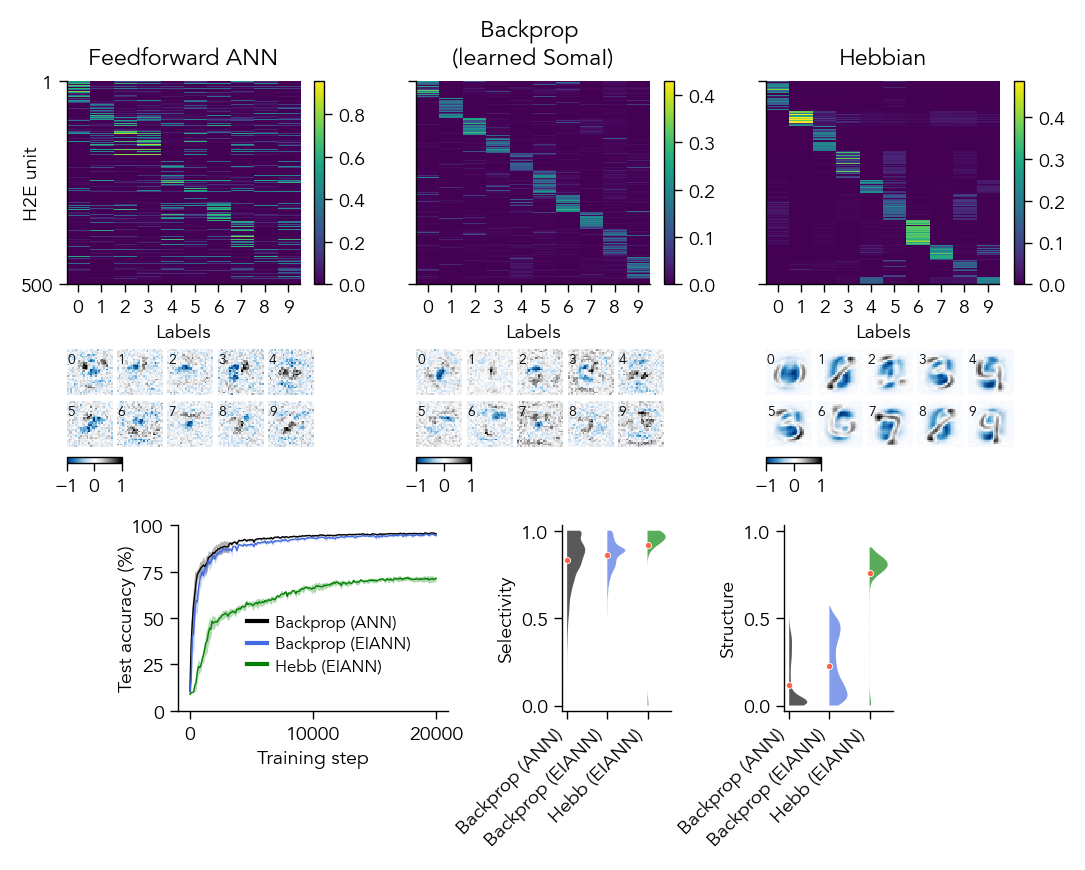

In [23]:
fig = plt.figure(figsize=(5.5, 9))
axes = gs.GridSpec(nrows=3, ncols=3, figure=fig,                    
                    left=0.049,right=0.95,
                    top=0.95, bottom=0.52,
                    wspace=0.2, hspace=0.4)
metrics_axes = gs.GridSpec(nrows=3, ncols=3, figure=fig,                        
                    left=0.15,right=0.8,
                    top=0.95, bottom=0.6,
                    wspace=0.7, hspace=0.2,
                    width_ratios=[2.5,1,1])

ax_accuracy    = fig.add_subplot(metrics_axes[2, 0])  
ax_selectivity = fig.add_subplot(metrics_axes[2, 1])
ax_structure   = fig.add_subplot(metrics_axes[2, 2])

for i,model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = hdf5_path_prefix + f"plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        seed = model_dict['seeds'][0] # example seed to plot
        population = 'H2E'

        # Activity plots: batch accuracy of each population to the test dataset
        ax = fig.add_subplot(axes[0, i])
        average_pop_activity_dict = data_dict[seed]['average_pop_activity_dict']
        num_units = average_pop_activity_dict[population].shape[1]

        pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)
        ax.set_yticks([0,num_units-1])
        ax.set_yticklabels([1,num_units])
        ax.set_ylabel(f'{population} unit', labelpad=-8)
        ax.set_title(model_dict["display_name"])
        if i>0:
            ax.set_ylabel('')
            ax.set_yticklabels([])

        # Receptive field plots
        receptive_fields = torch.tensor(np.array(data_dict[seed][f"maxact_receptive_fields_{population}"]))
        num_units = 10
        temp_ax = fig.add_subplot(axes[1, i])
        pos = temp_ax.get_position()
        temp_ax.remove()
        rf_axes = fig.add_gridspec(5,5,left=pos.x0, right=pos.x1-0.04, bottom=pos.y0-0.02, top=pos.y1+0.01, wspace=0.1, hspace=0.1)
        ax_list = []
        for j in range(num_units):
            _ax = fig.add_subplot(rf_axes[j])
            ax_list.append(_ax)
        preferred_classes = np.argmax(average_pop_activity_dict[population], axis=0)
        im = pt.plot_receptive_fields(receptive_fields, sort=True, ax_list=ax_list, preferred_classes=preferred_classes)
        fig_width, fig_height = fig.get_size_inches()
        cax = fig.add_axes([ax_list[0].get_position().x0, _ax.get_position().y0-0.08/fig_height, 0.05, 0.03/fig_height])
        fig.colorbar(im, cax=cax, orientation='horizontal')


        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E','H2E'], ax=ax_selectivity, metric_name='selectivity', plot_type='violin')
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E','H2E'], ax=ax_structure, metric_name='structure', plot_type='violin')
        # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E'], ax=ax_selectivity, metric_name='selectivity', plot_type='violin', side='low')
        # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E'], ax=ax_structure, metric_name='structure', plot_type='violin', side='low')
        # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H2E'], ax=ax_selectivity, metric_name='selectivity', plot_type='violin', side='high')
        # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H2E'], ax=ax_structure, metric_name='structure', plot_type='violin', side='high')

# fig.savefig(f"figures/{figure_name}.svg", dpi=300)
# fig.savefig(f"figures/{figure_name}.png", dpi=300)